In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para gráficos mais limpos e acadêmicos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Defina o caminho do seu arquivo (ajuste para .csv e pd.read_csv se necessário)
PATH = '06_Datasets.xlsx' 
df = pd.read_excel(PATH)

# Definindo o que é um benchmark clássico para fins de contraste 
# (Exemplo: CRED-002 é o South German Credit, CRED-004 é o Australian Credit)
classic_benchmarks = ['CRED-002', 'CRED-004'] 
df['Categoria'] = df['id'].apply(lambda x: 'Benchmark Clássico' if x in classic_benchmarks else 'Base Contemporânea')

print("Dados carregados com sucesso! Total de datasets:", len(df))

Dados carregados com sucesso! Total de datasets: 52


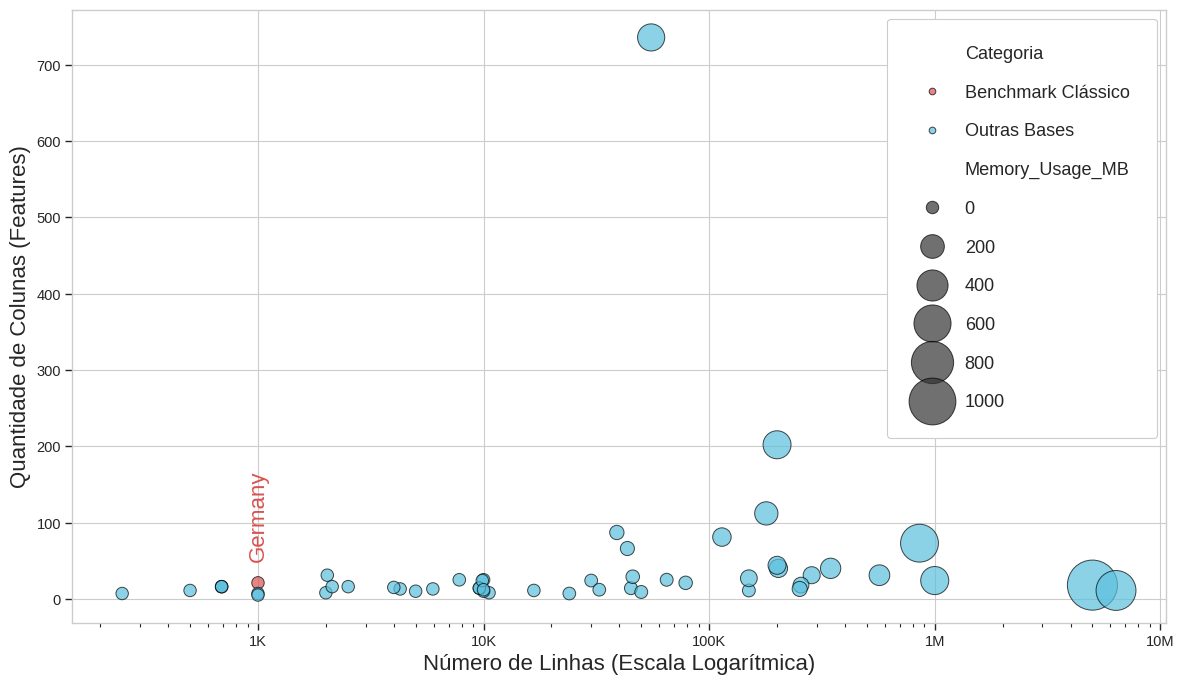

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configuração visual para padrão de publicação científica
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

PATH = '06_Datasets.xlsx' 
df = pd.read_excel(PATH)

classic_benchmarks = ['CRED-002'] 
df['Categoria'] = df['id'].apply(lambda x: 'Benchmark Clássico' if x in classic_benchmarks else 'Outras Bases')

# Função para formatar o eixo X (1K, 10K, 1M)
def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{int(x*1e-6)}M'
    elif x >= 1e3:
        return f'{int(x*1e-3)}K'
    else:
        return str(int(x))

plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=df, 
    x='Rows_Count', 
    y='Columns_Count', 
    hue='Categoria',
    size='Memory_Usage_MB', 
    sizes=(80, 1300),
    marker='o',
    palette={'Outras Bases': '#5bc0de', 'Benchmark Clássico': '#d9534f'},
    alpha=0.7,
    edgecolor='k'
)

plt.xscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(human_readable_format))
for index, row in df[df['Categoria'] == 'Benchmark Clássico'].iterrows():
    label_text = 'Germany' if row['id'] == 'CRED-002' else 'Australia'
        
    plt.annotate(
        label_text, 
        xy=(row['Rows_Count'], row['Columns_Count']), 
        xytext=(0, 15),           # Deslocamento vertical para cima do ponto
        textcoords='offset points',
        ha='center',              # Alinhamento horizontal centralizado
        va='bottom',              # Base do texto acima do ponto
        rotation=90,              # Rotação vertical solicitada
        fontsize=16, 
        color='#d9534f'
    )

plt.xlabel('Número de Linhas (Escala Logarítmica)', fontsize=16)
plt.ylabel('Quantidade de Colunas (Features)', fontsize=16)

# Legenda ajustada com maior preenchimento interno (borderpad) e espaçamento
plt.legend(
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    framealpha=1,
    borderpad=1.5,        # Aumenta o espaço entre o texto e a borda do bloco
    labelspacing=1.2,     # Aumenta o espaço vertical entre os itens
    fontsize=13,
    title_fontsize=13
)

plt.tight_layout()
plt.show()

In [14]:
# Certifique-se de que este código seja executado APÓS a criação da coluna 'Categoria'

print("="*40)
print("RESUMO DOS DADOS MAPEADOS NO GRÁFICO")
print("="*40, "\n")

# 1. Informações Gerais e Categorias (Hue)
print("--- CONTAGEM GERAL ---")
print(f"Total de bases de dados plotadas: {len(df)}")
print(f"Bases 'Benchmark Clássico': {len(df[df['Categoria'] == 'Benchmark Clássico'])}")
print(f"Bases 'Outras Bases': {len(df[df['Categoria'] == 'Outras Bases'])}\n")

# 2. Informações do Eixo X (Rows_Count)
print("--- EIXO X: NÚMERO DE LINHAS ---")
print(f"Menor quantidade de linhas: {df['Rows_Count'].min()}")
print(f"Maior quantidade de linhas: {df['Rows_Count'].max()}")
print(f"Média de linhas: {df['Rows_Count'].mean():.2f}")
print(f"Mediana de linhas: {df['Rows_Count'].median():.2f}\n")

# 3. Informações do Eixo Y (Columns_Count)
print("--- EIXO Y: QUANTIDADE DE COLUNAS ---")
print(f"Menor quantidade de colunas: {df['Columns_Count'].min()}")
print(f"Maior quantidade de colunas: {df['Columns_Count'].max()}")
print(f"Média de colunas: {df['Columns_Count'].mean():.2f}")
print(f"Mediana de colunas: {df['Columns_Count'].median():.2f}\n")

# 4. Informações do Tamanho das Bolhas (Memory_Usage_MB)
print("--- TAMANHO: USO DE MEMÓRIA (MB) ---")
print(f"Menor uso de memória: {df['Memory_Usage_MB'].min():.2f} MB")
print(f"Maior uso de memória: {df['Memory_Usage_MB'].max():.2f} MB")
print(f"Média uso de memória: {df['Memory_Usage_MB'].mean():.2f} MB")
print(f"Consumo total de memória (todas as bases): {df['Memory_Usage_MB'].sum():.2f} MB\n")

# 5. Detalhamento dos Pontos Anotados
print("--- DESTAQUES ANOTADOS NO GRÁFICO ---")
benchmarks = df[df['Categoria'] == 'Benchmark Clássico']
for index, row in benchmarks.iterrows():
    nome = 'Germany' if row['id'] == 'CRED-002' else 'Australia'
    print(f"Base: {nome} (ID: {row['id']})")
    print(f"  -> Posição X (Linhas): {row['Rows_Count']}")
    print(f"  -> Posição Y (Colunas): {row['Columns_Count']}")
    print(f"  -> Tamanho (Memória): {row['Memory_Usage_MB']:.2f} MB")
    print("-" * 30)

RESUMO DOS DADOS MAPEADOS NO GRÁFICO

--- CONTAGEM GERAL ---
Total de bases de dados plotadas: 52
Bases 'Benchmark Clássico': 1
Bases 'Outras Bases': 51

--- EIXO X: NÚMERO DE LINHAS ---
Menor quantidade de linhas: 250
Maior quantidade de linhas: 6362620
Média de linhas: 322256.48
Mediana de linhas: 27000.00

--- EIXO Y: QUANTIDADE DE COLUNAS ---
Menor quantidade de colunas: 5
Maior quantidade de colunas: 736
Média de colunas: 41.73
Mediana de colunas: 16.00

--- TAMANHO: USO DE MEMÓRIA (MB) ---
Menor uso de memória: 0.00 MB
Maior uso de memória: 1156.59 MB
Média uso de memória: 85.71 MB
Consumo total de memória (todas as bases): 4456.72 MB

--- DESTAQUES ANOTADOS NO GRÁFICO ---
Base: Germany (ID: CRED-002)
  -> Posição X (Linhas): 1000
  -> Posição Y (Colunas): 21
  -> Tamanho (Memória): 0.40 MB
------------------------------


In [11]:
import numpy as np

print("--- CONCENTRAÇÃO DE AMOSTRAS NO EIXO X (Rows_Count) ---")

# 1. Abordagem por Histograma Logarítmico (Intervalo mais populoso)
# Criamos 10 intervalos (bins) baseados na escala logarítmica (já que o gráfico usa log scale)
min_log = np.log10(df['Rows_Count'].min())
max_log = np.log10(df['Rows_Count'].max())
log_bins = np.logspace(min_log, max_log, num=10) # Altere o 'num' se quiser mais ou menos fatias

# Contamos quantas bases caem em cada intervalo
counts, bins = np.histogram(df['Rows_Count'], bins=log_bins)

# Pegamos o índice do intervalo com a maior contagem
max_bin_index = np.argmax(counts)

inicio_intervalo = bins[max_bin_index]
fim_intervalo = bins[max_bin_index + 1]
amostras_no_intervalo = counts[max_bin_index]
percentual = (amostras_no_intervalo / len(df)) * 100

print(f"O intervalo (fatia) com MAIOR concentração possui {amostras_no_intervalo} bases ({percentual:.1f}% do total).")
print(f"Ele ocorre no intervalo entre: {int(inicio_intervalo):,} e {int(fim_intervalo):,} linhas.\n".replace(',', '.'))

# 2. Abordagem por Quartis (Onde está o "miolo" dos dados)
q1 = df['Rows_Count'].quantile(0.25)
q3 = df['Rows_Count'].quantile(0.75)

print("Visualização da dispersão central (50% dos dados):")
print(f"A metade central de todas as amostras está concentrada no intervalo entre {int(q1):,} e {int(q3):,} linhas.".replace(',', '.'))
print("="*40)

--- CONCENTRAÇÃO DE AMOSTRAS NO EIXO X (Rows_Count) ---
O intervalo (fatia) com MAIOR concentração possui 10 bases (19.2% do total).
Ele ocorre no intervalo entre: 22.700 e 70.072 linhas.

Visualização da dispersão central (50% dos dados):
A metade central de todas as amostras está concentrada no intervalo entre 4.201 e 157.308 linhas.


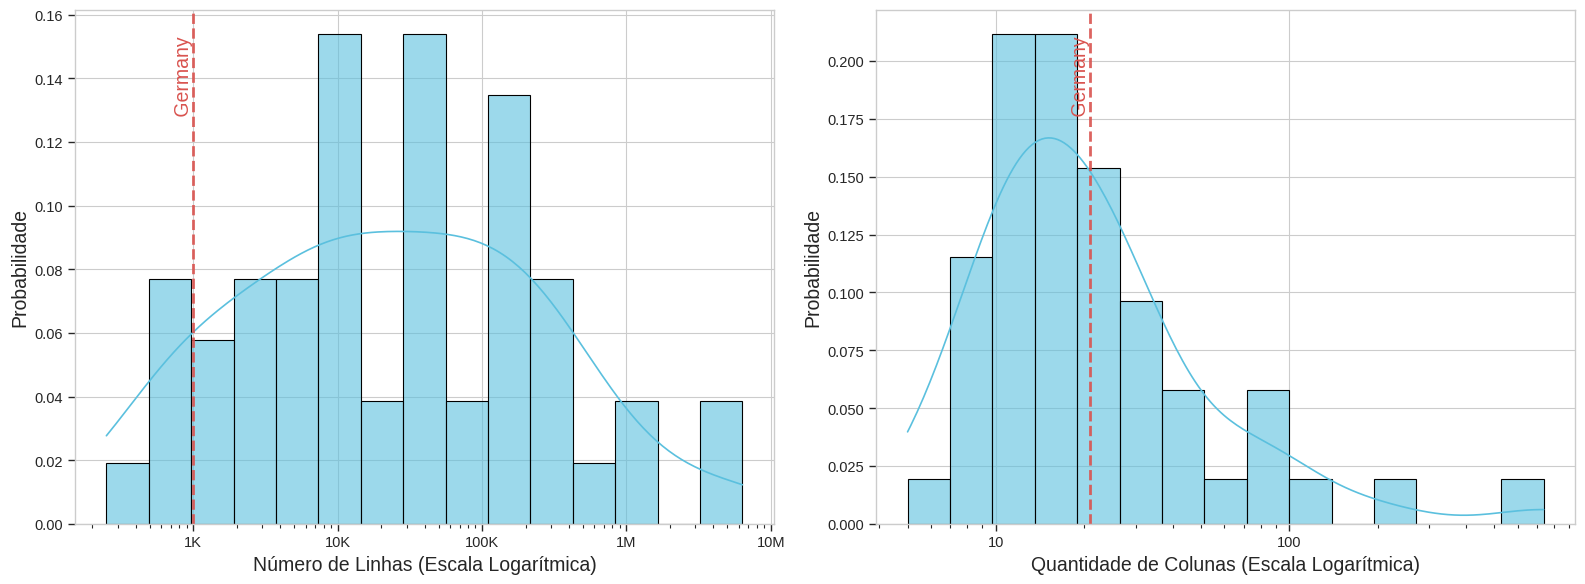

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configuração visual estabelecida para padrão de publicação científica
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

PATH = '06_Datasets.xlsx'
df = pd.read_excel(PATH)

classic_benchmarks = ['CRED-002']
df['Categoria'] = df['id'].apply(lambda x: 'Benchmark Clássico' if x in classic_benchmarks else 'Outras Bases')

# Função para formatar o eixo X (1K, 10K, 1M)
def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{int(x*1e-6)}M'
    elif x >= 1e3:
        return f'{int(x*1e-3)}K'
    else:
        return str(int(x))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# =====================================================================
# 1. GRÁFICO DA ESQUERDA: DISTRIBUIÇÃO DO NÚMERO DE LINHAS
# =====================================================================
sns.histplot(
    data=df, 
    x='Rows_Count', 
    kde=True,                  
    stat='probability',        
    color='#5bc0de',           
    edgecolor='black',
    alpha=0.6,
    log_scale=True,            
    bins=15,
    ax=ax1                     
)

ax1.xaxis.set_major_formatter(FuncFormatter(human_readable_format))
ymin1, ymax1 = ax1.get_ylim()

for index, row in df[df['Categoria'] == 'Benchmark Clássico'].iterrows():
    label_text = 'Germany' if row['id'] == 'CRED-002' else 'Australia'
    ax1.axvline(row['Rows_Count'], color='#d9534f', linestyle='--', linewidth=2, alpha=0.9)
    ax1.text(
        row['Rows_Count'], ymax1 * 0.95, f' {label_text}', 
        color='#d9534f', fontsize=14, rotation=90, va='top', ha='right'
    )

ax1.set_xlabel('Número de Linhas (Escala Logarítmica)', fontsize=14)
ax1.set_ylabel('Probabilidade', fontsize=14)

# =====================================================================
# 2. GRÁFICO DA DIREITA: DISTRIBUIÇÃO DO NÚMERO DE COLUNAS
# =====================================================================
sns.histplot(
    data=df, 
    x='Columns_Count', 
    kde=True,                  
    stat='probability',        
    color='#5bc0de',           
    edgecolor='black',
    alpha=0.6,
    log_scale=True,            # Alteração solicitada: Escala agora é True
    bins=15,
    ax=ax2                     
)

# Adicionado o mesmo formatador visual para o eixo X do segundo gráfico
ax2.xaxis.set_major_formatter(FuncFormatter(human_readable_format))
ymin2, ymax2 = ax2.get_ylim()

for index, row in df[df['Categoria'] == 'Benchmark Clássico'].iterrows():
    label_text = 'Germany' if row['id'] == 'CRED-002' else 'Australia'
    ax2.axvline(row['Columns_Count'], color='#d9534f', linestyle='--', linewidth=2, alpha=0.9)
    ax2.text(
        row['Columns_Count'], ymax2 * 0.95, f' {label_text}', 
        color='#d9534f', fontsize=14, rotation=90, va='top', ha='right'
    )

# Atualizado o rótulo do eixo X para refletir a nova escala
ax2.set_xlabel('Quantidade de Colunas (Escala Logarítmica)', fontsize=14)
ax2.set_ylabel('Probabilidade', fontsize=14)

plt.tight_layout()
plt.show()

In [34]:
import numpy as np

def print_interval_probabilities(df, column_name, bins=15):
    """
    Calcula e imprime a probabilidade de cada intervalo (bin) utilizado no histplot
    com log_scale=True, revertendo a exibição dos limites para a escala normal.
    """
    # Removendo possíveis valores nulos ou zeros (log de zero é indefinido)
    data = df[column_name].replace(0, np.nan).dropna()
    
    # Aplicando o logaritmo na base 10 (exatamente como o Seaborn faz)
    log_data = np.log10(data)
    
    # Calculando o histograma no espaço logarítmico
    counts, log_bin_edges = np.histogram(log_data, bins=bins)
    
    # Transformando a contagem absoluta em probabilidade (de 0 a 1)
    probabilities = counts / len(data)
    
    # Revertendo os limites dos bins do espaço logarítmico para a escala normal
    normal_bin_edges = 10 ** log_bin_edges
    
    print(f"--- Distribuição de Probabilidades: {column_name} ---")
    for i in range(len(counts)):
        inicio = normal_bin_edges[i]
        fim = normal_bin_edges[i+1]
        prob_pct = probabilities[i] * 100  # Convertido para porcentagem
        
        # Omitindo intervalos vazios para manter o terminal limpo
        if prob_pct > 0:
            print(f"Intervalo {i+1:02d} | De {inicio:12.1f} até {fim:12.1f} -> Probabilidade: {prob_pct:5.2f}%")
            
    print("-" * 65, "\n")

# =====================================================================
# CHAMANDO A FUNÇÃO PARA OS SEUS DADOS
# =====================================================================
# Você pode colar este bloco no final do seu script, logo antes ou depois do plt.show()

print_interval_probabilities(df, 'Rows_Count', bins=15)
print_interval_probabilities(df, 'Columns_Count', bins=15)
print_interval_probabilities(df, 'Memory_Usage_MB', bins=15)

--- Distribuição de Probabilidades: Rows_Count ---
Intervalo 01 | De        250.0 até        491.6 -> Probabilidade:  1.92%
Intervalo 02 | De        491.6 até        966.9 -> Probabilidade:  7.69%
Intervalo 03 | De        966.9 até       1901.4 -> Probabilidade:  5.77%
Intervalo 04 | De       1901.4 até       3739.3 -> Probabilidade:  7.69%
Intervalo 05 | De       3739.3 até       7353.7 -> Probabilidade:  7.69%
Intervalo 06 | De       7353.7 até      14461.7 -> Probabilidade: 15.38%
Intervalo 07 | De      14461.7 até      28440.1 -> Probabilidade:  3.85%
Intervalo 08 | De      28440.1 até      55930.0 -> Probabilidade: 15.38%
Intervalo 09 | De      55930.0 até     109991.1 -> Probabilidade:  3.85%
Intervalo 10 | De     109991.1 até     216307.0 -> Probabilidade: 13.46%
Intervalo 11 | De     216307.0 até     425386.5 -> Probabilidade:  7.69%
Intervalo 12 | De     425386.5 até     836559.4 -> Probabilidade:  1.92%
Intervalo 13 | De     836559.4 até    1645166.5 -> Probabilidade:  3.85%


/tmp/ipykernel_135352/3397643766.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels, rotation=90, fontsize=9)


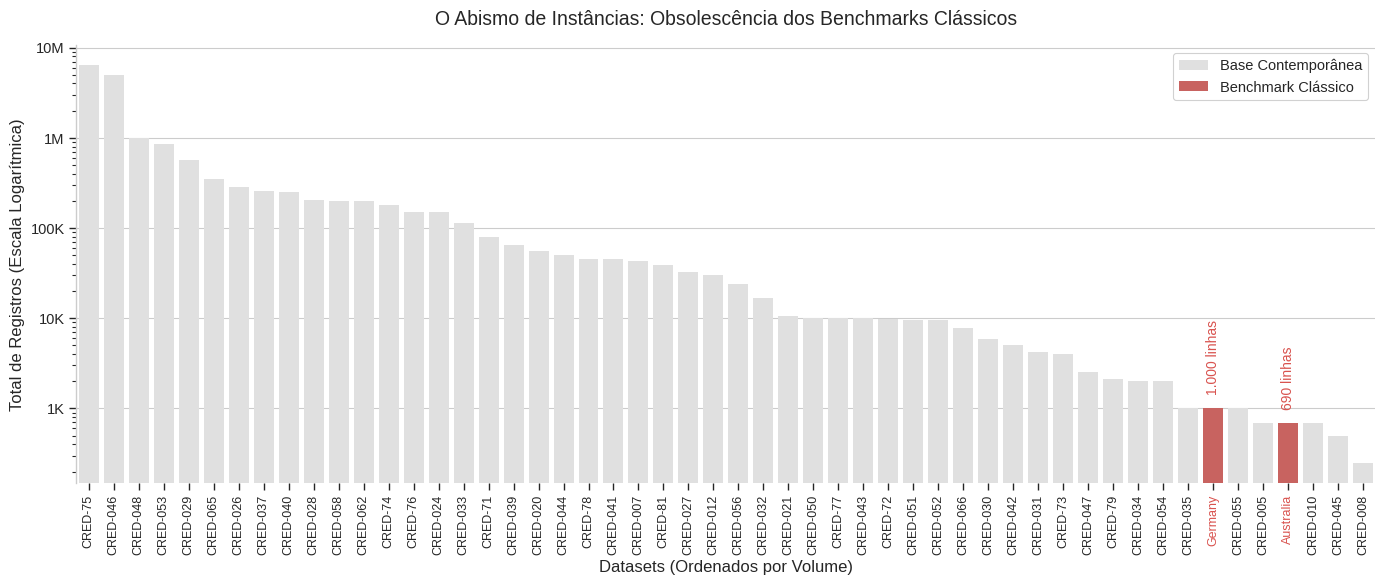

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# (Garantindo a criação da categoria, caso não esteja na célula)
classic_benchmarks = ['CRED-002', 'CRED-004'] 
df['Categoria'] = df['id'].apply(lambda x: 'Benchmark Clássico' if x in classic_benchmarks else 'Base Contemporânea')

# Ajustando a proporção para um gráfico vertical (mais largo do que alto)
plt.figure(figsize=(14, 6))

# Ordenando de forma decrescente para que a maior barra fique na esquerda
df_sorted = df.sort_values(by='Rows_Count', ascending=False).reset_index(drop=True)

# Criando o gráfico vertical (X e Y invertidos)
ax = sns.barplot(
    data=df_sorted,
    x='id',
    y='Rows_Count',
    hue='Categoria',
    palette={'Benchmark Clássico': '#d9534f', 'Base Contemporânea': '#e0e0e0'},
    dodge=False,
    edgecolor='none'
)

# Escala logarítmica agora no eixo Y
plt.yscale('log')

# Função para formatar o eixo Y (1K, 10K, 1M)
def human_readable_format(y, pos):
    if y >= 1e6:
        return f'{int(y*1e-6)}M'
    elif y >= 1e3:
        return f'{int(y*1e-3)}K'
    else:
        return str(int(y))

ax.yaxis.set_major_formatter(FuncFormatter(human_readable_format))

# Lógica para mostrar todos os IDs e destacar apenas os clássicos
new_x_labels = []
for tick in ax.get_xticklabels():
    dataset_id = tick.get_text()
    if dataset_id == 'CRED-002':
        new_x_labels.append('Germany')
        tick.set_color('#d9534f')
    elif dataset_id == 'CRED-004':
        new_x_labels.append('Australia')
        tick.set_color('#d9534f')
    else:
        # Agora mantemos o ID da base em vez de deixar em branco
        new_x_labels.append(dataset_id) 

# Aplicando os rótulos com rotação de 90 graus e tamanho de fonte ajustado
ax.set_xticklabels(new_x_labels, rotation=90, fontsize=9)

# Removendo a linha preta inferior para um visual mais limpo
sns.despine(left=False, bottom=True)

# Adicionando o número exato de linhas no topo das barras vermelhas
for i, row in df_sorted.iterrows():
    if row['Categoria'] == 'Benchmark Clássico':
        # Formatação para padrão brasileiro de milhares
        linhas_formatado = f"{int(row['Rows_Count']):,}".replace(',', '.')
        
        ax.annotate(
            f"{linhas_formatado} linhas", 
            xy=(i, row['Rows_Count']),  # Coordenada invertida (X, Y)
            xytext=(0, 10),             # 10 pixels de distância acima da barra
            textcoords='offset points',
            ha='center',                # Centralizado em relação à barra
            va='bottom',                # Acima do ponto âncora
            color='#d9534f',
            fontsize=10,
            rotation=90                 # Rotacionado para caber na largura da barra
        )

plt.title('O Abismo de Instâncias: Obsolescência dos Benchmarks Clássicos', fontsize=14, pad=15)
plt.xlabel('Datasets (Ordenados por Volume)', fontsize=12)
plt.ylabel('Total de Registros (Escala Logarítmica)', fontsize=12)

# Ajustando a legenda para o topo
plt.legend(title='', loc='upper right', frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para padrão acadêmico
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Carregamento da base
PATH = '06_Datasets.xlsx'
df = pd.read_excel(PATH)

# Criando rótulos legíveis para os gráficos
df['Status_Criptografia'] = df['is_encrypted'].map({1: 'Criptografado (Ofuscado)', 0: 'Aberto (Não Criptografado)'})
df['Permite_Auditoria'] = df['Has_Sensitive_Data'].map({True: 'Possui Atributos Sensíveis', False: 'Sem Atributos Sensíveis'})

print("Dados preparados! Distribuição de Criptografia:")
print(df['Status_Criptografia'].value_counts())

Dados preparados! Distribuição de Criptografia:
Status_Criptografia
Aberto (Não Criptografado)    38
Criptografado (Ofuscado)      14
Name: count, dtype: int64


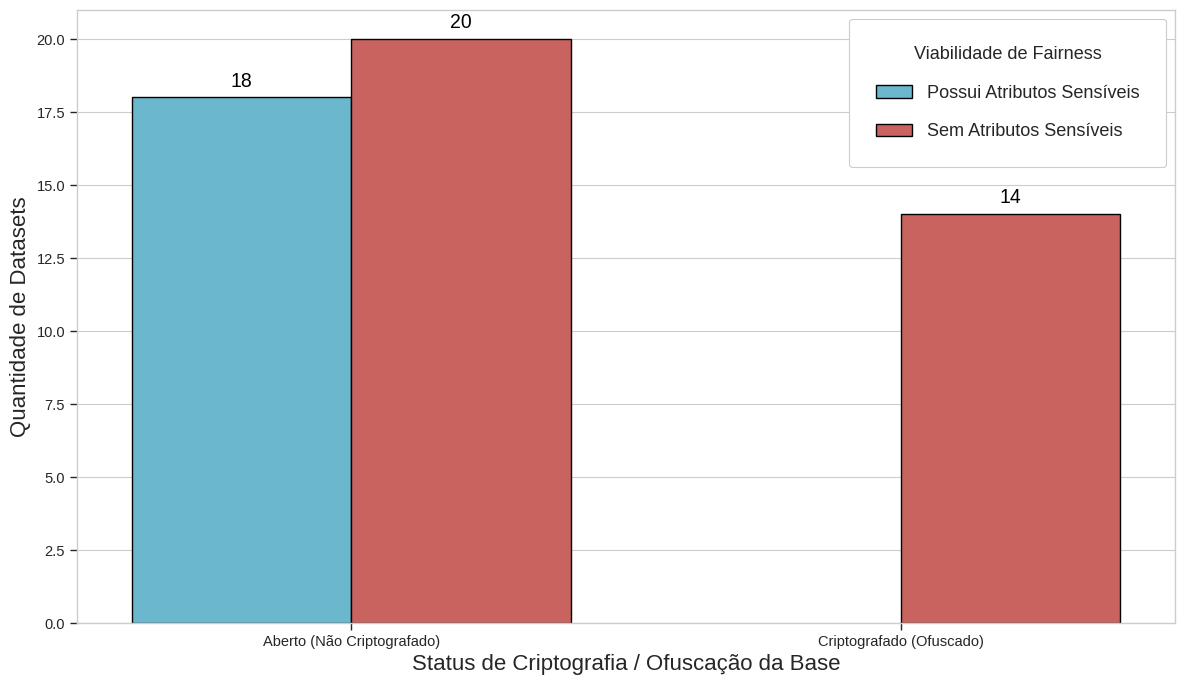

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=df, 
    x='Status_Criptografia', 
    hue='Permite_Auditoria',
    palette={'Possui Atributos Sensíveis': '#5bc0de', 'Sem Atributos Sensíveis': '#d9534f'},
    edgecolor='black',
    linewidth=1
)
plt.xlabel('Status de Criptografia / Ofuscação da Base', fontsize=16)
plt.ylabel('Quantidade de Datasets', fontsize=16)
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=14, color='black', xytext=(0, 5), 
                    textcoords='offset points')

plt.legend(
    title='Viabilidade de Fairness', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    framealpha=1,
    borderpad=1.5,        # Espaço entre o texto e a borda do bloco
    labelspacing=1.2,     # Espaço vertical entre os itens
    fontsize=13,
    title_fontsize=13
)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

# 1. Carregamento e limpeza dos dados
df = df.dropna(subset=['id'])  # Garante que estamos analisando apenas linhas com dados

# 2. Mapeamento de variáveis para os nomes amigáveis do gráfico
df['Status_Criptografia'] = df['is_encrypted'].map({
    0: 'Legível para Humanos', 
    1: 'Criptografado/Ofuscado'
})

df['Permite_Auditoria'] = df['Has_Sensitive_Data'].map({
    True: 'Possui Atributos Sensíveis', 
    False: 'Sem Atributos Sensíveis'
})

# 3. Geração da Tabela de Frequência (Crosstab)
tabela_frequencia = pd.crosstab(df['Status_Criptografia'], df['Permite_Auditoria'])

# 4. Cálculo de Percentuais
total_datasets = len(df)
stats = df.groupby(['Status_Criptografia', 'Permite_Auditoria']).size().reset_index(name='Quantidade')
stats['Percentual (%)'] = (stats['Quantidade'] / total_datasets * 100).round(2)

# 5. Exibição dos resultados no terminal
print(f"Total de Datasets Analisados: {total_datasets}\n")
print("--- Contagem por Categoria (Tabela do Gráfico) ---")
print(tabela_frequencia)
print("\n--- Estatísticas Detalhadas para o Texto do Artigo ---")
print(stats.to_string(index=False))

Total de Datasets Analisados: 52

--- Contagem por Categoria (Tabela do Gráfico) ---
Permite_Auditoria       Possui Atributos Sensíveis  Sem Atributos Sensíveis
Status_Criptografia                                                        
Criptografado/Ofuscado                           0                       14
Legível para Humanos                            18                       20

--- Estatísticas Detalhadas para o Texto do Artigo ---
   Status_Criptografia          Permite_Auditoria  Quantidade  Percentual (%)
Criptografado/Ofuscado    Sem Atributos Sensíveis          14           26.92
  Legível para Humanos Possui Atributos Sensíveis          18           34.62
  Legível para Humanos    Sem Atributos Sensíveis          20           38.46


In [6]:
import pandas as pd
import numpy as np

# 1. Carregamento dos dados
# Substitua o nome do arquivo pelo caminho correto no seu ambiente

print("=== ESTATÍSTICAS GERAIS DA AMOSTRA ===")
total_datasets = len(df)
print(f"Total de datasets analisados: {total_datasets}")

# 2. Dimensão e Volume (Linhas e Colunas)
# Extraindo média, mediana, mínimo e máximo para mostrar a diversidade
print("\n=== DISTRIBUIÇÃO DE VOLUME (LINHAS E COLUNAS) ===")
print("Linhas (Instâncias):")
print(f"- Média: {df['Rows_Count'].mean():.2f}")
print(f"- Mediana: {df['Rows_Count'].median():.2f}")
print(f"- Mínimo: {df['Rows_Count'].min()} | Máximo: {df['Rows_Count'].max()}")

print("\nColunas (Atributos):")
print(f"- Média: {df['Columns_Count'].mean():.2f}")
print(f"- Mediana: {df['Columns_Count'].median():.2f}")
print(f"- Mínimo: {df['Columns_Count'].min()} | Máximo: {df['Columns_Count'].max()}")

# 3. Viabilidade para Fairness (Atributos Sensíveis)
# Métrica crucial para responder à sua pergunta de pesquisa
print("\n=== VIABILIDADE PARA IA JUSTA (FAIRNESS) ===")
datasets_com_sensiveis = df['Has_Sensitive_Data'].sum()
pct_sensiveis = (datasets_com_sensiveis / total_datasets) * 100

print(f"Datasets com atributos sensíveis: {datasets_com_sensiveis} ({pct_sensiveis:.2f}%)")

# Quantidade média de atributos sensíveis nos datasets que os possuem
media_sensiveis = df[df['Has_Sensitive_Data'] == True]['Sensitive_Count'].mean()
print(f"Média de atributos sensíveis (apenas nos que possuem): {media_sensiveis:.2f}")

# 4. Qualidade Técnica dos Dados
print("\n=== QUALIDADE E INTEGRIDADE DOS DADOS ===")
datasets_com_nulos = len(df[df['Rows_With_Missing'] > 0])
pct_nulos = (datasets_com_nulos / total_datasets) * 100

print(f"Datasets com valores ausentes: {datasets_com_nulos} ({pct_nulos:.2f}%)")
print(f"Esparsidade média geral: {df['Sparsity_Ratio_%'].mean():.2f}%")
print(f"Razão de dimensionalidade média: {df['Dimensionality_Ratio'].mean():.4f}")

# 5. Comparativo: Datasets Novos vs Benchmarks Clássicos
print("\n=== CONTRASTE COM BENCHMARKS ===")
benchmarks_ids = ['CRED-002', 'CRED-004'] # IDs do German Credit e Australian Credit
benchmarks = df[df['id'].isin(benchmarks_ids)]
outros = df[~df['id'].isin(benchmarks_ids)]

print(f"Média de linhas (Benchmarks): {benchmarks['Rows_Count'].mean():.2f}")
print(f"Média de linhas (Novos Datasets): {outros['Rows_Count'].mean():.2f}")

=== ESTATÍSTICAS GERAIS DA AMOSTRA ===
Total de datasets analisados: 52

=== DISTRIBUIÇÃO DE VOLUME (LINHAS E COLUNAS) ===
Linhas (Instâncias):
- Média: 322256.48
- Mediana: 27000.00
- Mínimo: 250 | Máximo: 6362620

Colunas (Atributos):
- Média: 41.73
- Mediana: 16.00
- Mínimo: 5 | Máximo: 736

=== VIABILIDADE PARA IA JUSTA (FAIRNESS) ===
Datasets com atributos sensíveis: 18 (34.62%)
Média de atributos sensíveis (apenas nos que possuem): 1.67

=== QUALIDADE E INTEGRIDADE DOS DADOS ===
Datasets com valores ausentes: 20 (38.46%)
Esparsidade média geral: 2.58%
Razão de dimensionalidade média: 0.0045

=== CONTRASTE COM BENCHMARKS ===
Média de linhas (Benchmarks): 845.00
Média de linhas (Novos Datasets): 335112.94


In [36]:
import pandas as pd

print("=== ANÁLISE DE QUALIDADE E DADOS AUSENTES ===")
# Datasets que possuem algum valor nulo
datasets_sujos = df[df['Rows_With_Missing'] > 0]
pct_sujos = (len(datasets_sujos) / len(df)) * 100

print(f"Bases com dados ausentes (Missing Values): {len(datasets_sujos)} ({pct_sujos:.2f}%)")
print(f"Média de esparsidade geral: {df['Sparsity_Ratio_%'].mean():.2f}%")

print("\n=== ANÁLISE DE TIPAGEM (CATEGÓRICOS VS NUMÉRICOS) ===")
# Media de colunas de cada tipo nas bases que não são o baseline
outras_bases = df[~df['id'].isin(['CRED-002', 'CRED-004'])]

media_num = outras_bases['Numeric_Cols'].mean()
media_cat = outras_bases['Categorical_Cols'].mean()

print(f"Nas bases modernas, a média é de {media_num:.2f} colunas numéricas e {media_cat:.2f} categóricas.")

# Comparação com o baseline (German Credit)
german = df[df['id'] == 'CRED-002'].iloc[0]
print(f"No baseline (German Credit), são {german['Numeric_Cols']} numéricas e {german['Categorical_Cols']} categóricas.")

=== ANÁLISE DE QUALIDADE E DADOS AUSENTES ===
Bases com dados ausentes (Missing Values): 20 (38.46%)
Média de esparsidade geral: 2.58%

=== ANÁLISE DE TIPAGEM (CATEGÓRICOS VS NUMÉRICOS) ===
Nas bases modernas, a média é de 35.74 colunas numéricas e 6.92 categóricas.
No baseline (German Credit), são 3 numéricas e 18 categóricas.


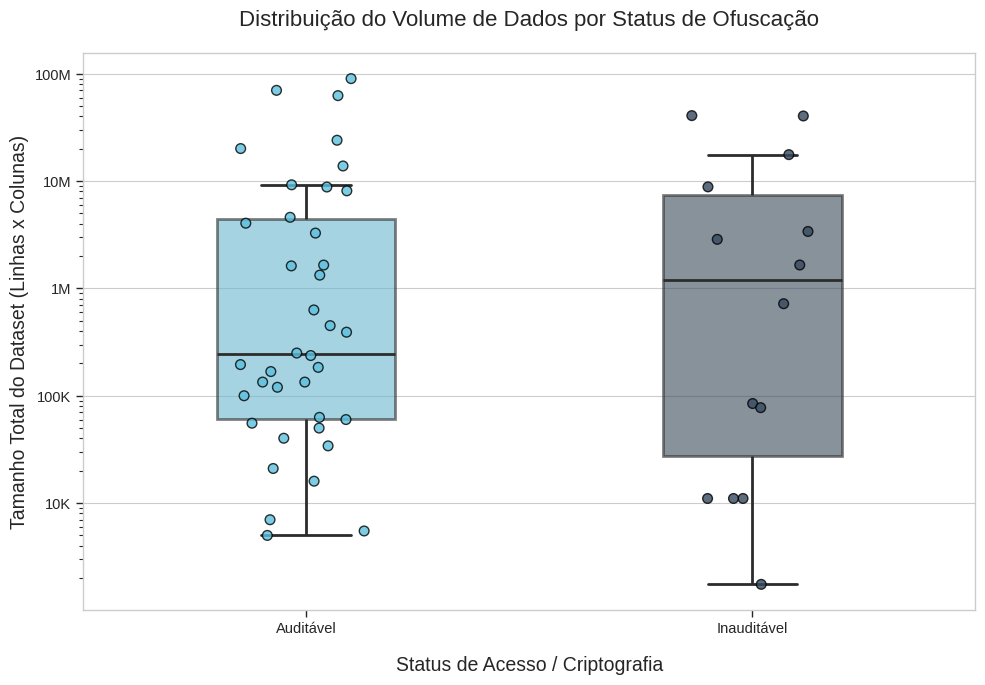

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
PATH = '06_Datasets.xlsx'
df = pd.read_excel(PATH)
df['Tamanho_Total'] = df['Rows_Count'] * df['Columns_Count']
df['Status_Criptografia'] = df['is_encrypted'].map({0: 'Auditável', 1: 'Inauditável'})
df = df.dropna(subset=['Status_Criptografia'])
def human_readable_format_large(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{int(x*1e-6)}M'
    elif x >= 1e3:
        return f'{int(x*1e-3)}K'
    else:
        return str(int(x))

fig, ax = plt.subplots(figsize=(10, 7))

# Definindo cores (Azul para padrão, Cinza escuro para encriptado/caixa-preta)
paleta = {'Auditável': '#5bc0de', 'Inauditável': '#34495e'}
ordem = ['Auditável', 'Inauditável']

# Plotando o Boxplot para mostrar a distribuição estatística e os quartis
sns.boxplot(
    data=df, 
    x='Status_Criptografia', 
    y='Tamanho_Total', 
    hue='Status_Criptografia',
    order=ordem,
    palette=paleta,
    width=0.4,
    linewidth=2,
    boxprops=dict(alpha=0.6), # Deixa a caixa levemente transparente
    showfliers=False,         # Oculta os outliers nativos do boxplot
    legend=False,
    ax=ax
)

# Plotando o Stripplot (pontos individuais) por cima da caixa
sns.stripplot(
    data=df, 
    x='Status_Criptografia', 
    y='Tamanho_Total', 
    hue='Status_Criptografia',
    order=ordem,
    palette=paleta,
    size=7,
    jitter=0.15,              # Espalha os pontos horizontalmente
    alpha=0.8,
    edgecolor='black',
    linewidth=1,
    legend=False,
    ax=ax
)

# Configurando o eixo Y para escala logarítmica (crucial para volumes de dados)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(FuncFormatter(human_readable_format_large))

ax.set_xlabel('Status de Acesso / Criptografia', fontsize=14, labelpad=15)
ax.set_ylabel('Tamanho Total do Dataset (Linhas x Colunas)', fontsize=14)
ax.set_title('Distribuição do Volume de Dados por Status de Ofuscação', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import numpy as np

# Carregando os dados
PATH = '06_Datasets.xlsx'
df = pd.read_excel(PATH)

# Preparação idêntica ao gráfico
df['Tamanho_Total'] = df['Rows_Count'] * df['Columns_Count']
df['Status_Criptografia'] = df['is_encrypted'].map({0: 'Auditável', 1: 'Inauditável'})
df = df.dropna(subset=['Status_Criptografia'])

# Função para deixar os números mais legíveis no terminal
def formatar_numero(x):
    if x >= 1e9:
        return f'{x*1e-9:.2f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.2f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.2f}K'
    else:
        return f'{int(x)}'

print("="*60)
print(" RESUMO ESTATÍSTICO: TAMANHO DO DATASET VS OFUSCAÇÃO")
print("="*60, "\n")

# 1. Contagem Geral (Equivalente à proporção do gráfico de rosca anterior)
total_bases = len(df)
auditaveis = len(df[df['Status_Criptografia'] == 'Auditável'])
inauditaveis = len(df[df['Status_Criptografia'] == 'Inauditável'])

print("--- CONTAGEM GERAL ---")
print(f"Total de Bases Analisadas: {total_bases}")
print(f" - Auditáveis (0):   {auditaveis} ({(auditaveis/total_bases)*100:.1f}%)")
print(f" - Inauditáveis (1): {inauditaveis} ({(inauditaveis/total_bases)*100:.1f}%)\n")

# 2. Estatísticas Detalhadas por Categoria (Equivalente ao Boxplot)
ordem_status = ['Auditável', 'Inauditável']

for status in ordem_status:
    grupo = df[df['Status_Criptografia'] == status]
    
    if len(grupo) > 0:
        # Cálculos estatísticos
        menor = grupo['Tamanho_Total'].min()
        maior = grupo['Tamanho_Total'].max()
        media = grupo['Tamanho_Total'].mean()
        mediana = grupo['Tamanho_Total'].median()
        q1 = grupo['Tamanho_Total'].quantile(0.25) # Início da caixa
        q3 = grupo['Tamanho_Total'].quantile(0.75) # Fim da caixa
        
        # Identificação nominal dos extremos
        nome_maior = grupo.loc[grupo['Tamanho_Total'].idxmax(), 'id']
        nome_menor = grupo.loc[grupo['Tamanho_Total'].idxmin(), 'id']
        
        print(f"--- DISTRIBUIÇÃO: STATUS {status.upper()} ---")
        print(f" Menor base: {formatar_numero(menor):>8} células (ID: {nome_menor})")
        print(f" Maior base: {formatar_numero(maior):>8} células (ID: {nome_maior})")
        print(f" Média:      {formatar_numero(media):>8} células")
        print(f" Mediana:    {formatar_numero(mediana):>8} células (Linha central da caixa)")
        print(f" Quartil 1:  {formatar_numero(q1):>8} células (Início da caixa azul/cinza)")
        print(f" Quartil 3:  {formatar_numero(q3):>8} células (Fim da caixa azul/cinza)")
        print("-" * 50, "\n")

 RESUMO ESTATÍSTICO: TAMANHO DO DATASET VS OFUSCAÇÃO

--- CONTAGEM GERAL ---
Total de Bases Analisadas: 52
 - Auditáveis (0):   38 (73.1%)
 - Inauditáveis (1): 14 (26.9%)

--- DISTRIBUIÇÃO: STATUS AUDITÁVEL ---
 Menor base:    5.00K células (ID: CRED-055)
 Maior base:   90.00M células (ID: CRED-046)
 Média:         8.59M células
 Mediana:     243.45K células (Linha central da caixa)
 Quartil 1:    60.72K células (Início da caixa azul/cinza)
 Quartil 3:     4.46M células (Fim da caixa azul/cinza)
-------------------------------------------------- 

--- DISTRIBUIÇÃO: STATUS INAUDITÁVEL ---
 Menor base:    1.75K células (ID: CRED-008)
 Maior base:   40.71M células (ID: CRED-020)
 Média:         8.31M células
 Mediana:       1.19M células (Linha central da caixa)
 Quartil 1:    27.65K células (Início da caixa azul/cinza)
 Quartil 3:     7.47M células (Fim da caixa azul/cinza)
-------------------------------------------------- 



In [1]:
import pandas as pd
from scipy import stats

# 1. Carregamento e Preparação dos Dados (conforme seu notebook)
PATH = '06_Datasets.xlsx'
df = pd.read_excel(PATH)
df['Tamanho_Total'] = df['Rows_Count'] * df['Columns_Count']

# Limpeza de valores nulos nas colunas de interesse
df_clean = df.dropna(subset=['is_encrypted', 'Tamanho_Total'])

# ---------------------------------------------------------
# 2. Correlação de Spearman (Recomendada para esta amostra)
# ---------------------------------------------------------
# Avalia a relação monotônica. Ideal porque a variável 'Tamanho_Total'
# possui uma assimetria severa e picos muito altos.
corr_spearman, p_valor_spearman = stats.spearmanr(df_clean['is_encrypted'], df_clean['Tamanho_Total'])

print("=== CORRELAÇÃO DE SPEARMAN ===")
print(f"Coeficiente: {corr_spearman:.4f}")
print(f"P-valor: {p_valor_spearman:.4f}\n")

# ---------------------------------------------------------
# 3. Correlação Ponto-Bisserial (Método Clássico)
# ---------------------------------------------------------
# Medida padrão para uma variável contínua e outra binária,
# mas que pressupõe que a variável contínua seja minimamente normal.
corr_pb, p_valor_pb = stats.pointbiserialr(df_clean['is_encrypted'], df_clean['Tamanho_Total'])

print("=== CORRELAÇÃO PONTO-BISSERIAL ===")
print(f"Coeficiente: {corr_pb:.4f}")
print(f"P-valor: {p_valor_pb:.4f}")

=== CORRELAÇÃO DE SPEARMAN ===
Coeficiente: 0.0029
P-valor: 0.9838

=== CORRELAÇÃO PONTO-BISSERIAL ===
Coeficiente: -0.0065
P-valor: 0.9635
